# Classical Codes: Define, Distance, Distance Distribution

Sampling random parity-check matrices, comparing distance distributions, and basic ClassicalCode / LogicalChannel sanity checks. Sampling helpers live in `random_codes.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ClassicalCode import ClassicalCode
from LogicalChannel import LogicalChannel, partial_trace_syndrome
from measures import logical_basis_state
from random_codes import sample_H, sample_H_brute, distance_distribution

### Distance distributions for two different Parity check matrix generation

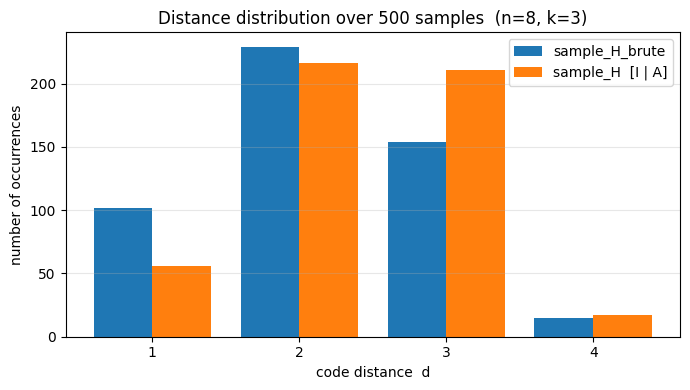

sample_H_brute: {1: 102, 2: 229, 3: 154, 4: 15}
sample_H      : {1: 56, 2: 216, 3: 211, 4: 17}


In [2]:
# ---- Compare distance distributions of the two sampling methods ----
n, k      = 8, 3
n_samples = 500

dist_brute = distance_distribution(lambda: sample_H_brute(n, k), n_samples)
dist_std   = distance_distribution(lambda: sample_H(n, k),       n_samples)

all_d = sorted(set(dist_brute) | set(dist_std))
x     = np.arange(len(all_d))
w     = 0.4

plt.figure(figsize=(7, 4))
plt.bar(x - w / 2, [dist_brute.get(d, 0) for d in all_d], width=w, label='sample_H_brute')
plt.bar(x + w / 2, [dist_std.get(d, 0)   for d in all_d], width=w, label='sample_H  [I | A]')
plt.xticks(x, all_d)
plt.xlabel('code distance  d')
plt.ylabel('number of occurrences')
plt.title(f'Distance distribution over {n_samples} samples  (n={n}, k={k})')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('sample_H_brute:', dist_brute)
print('sample_H      :', dist_std)

## Classical Code Define

In [3]:
code = ClassicalCode(np.array([[1, 1, 0],
                                [0, 1, 1]]))
print(code)


ClassicalCode(n=3, k=1, m=2)


In [4]:
n, k = 3, 1
code_random1 = ClassicalCode(sample_H(n,k))
code_random2 = ClassicalCode(sample_H_brute(n,k))
print(code_random1)
print(code_random1.d)

ClassicalCode(n=3, k=1, m=2)
1


In [5]:
# ---- Sanity checks ----
ch_test = LogicalChannel(code, 3, 0.1)
assert np.allclose(ch_test.U @ ch_test.U.T, np.eye(code.dim)), 'U is not unitary'
_rho_test = np.array([[0.7, 0.0], [0.0, 0.3]], dtype=complex)
assert np.allclose(ch_test(0, _rho_test), _rho_test), 'logical_channel(0) is not identity'
print('LogicalChannel.U is unitary (U @ U.T = I)')
print('LogicalChannel t=0 is identity on logical space')

LogicalChannel.U is unitary (U @ U.T = I)
LogicalChannel t=0 is identity on logical space


In [6]:
U = code.build_logical_unitary()
U_dag = U.T.conj()

print(U)

#print(code.x_string([1, 1, 1]))
M = U @ (0.3 * code.basis_state(0) + 0.7 * code.basis_state(7)) @ U_dag

print(partial_trace_syndrome(M, code))

[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]]
[[0.3+0.j 0. +0.j]
 [0. +0.j 0.7+0.j]]
